In [1]:
#Install requirements
%pip install -r "../requirements.txt"

Note: you may need to restart the kernel to use updated packages.


In [2]:
#Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix, 
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    ConfusionMatrixDisplay)

import os
import scipy
from scipy.stats import pearsonr

In [ ]:
#Import the data

if not os.path.exists("../data/processed"):
    print("Processed Data Path does not exist. Expected in `../data/processed`. Run first data_exploration.ipynb")
    exit

#Load Training Data
X_train_cpg = pd.read_pickle('../data/processed/X_train_cpg.pkl')
y_train = pd.read_pickle('../data/processed/y_train.pkl')

#Load Validation Data
X_val_cpg = pd.read_pickle('../data/processed/X_val_cpg.pkl')
y_val = pd.read_pickle('../data/processed/y_val.pkl')

print('Data for training and validation set loaded successfully')

Data for training and validation set loaded successfully


In [4]:
import os
import sys

#Add the src to the path
sys.path.append(os.path.abspath(os.path.join('..')))

In [5]:
#Apply stability selection for feature selection 

from src.functions import stability_selection

top200_allsubsamples = stability_selection(X_train_cpg, y_train)

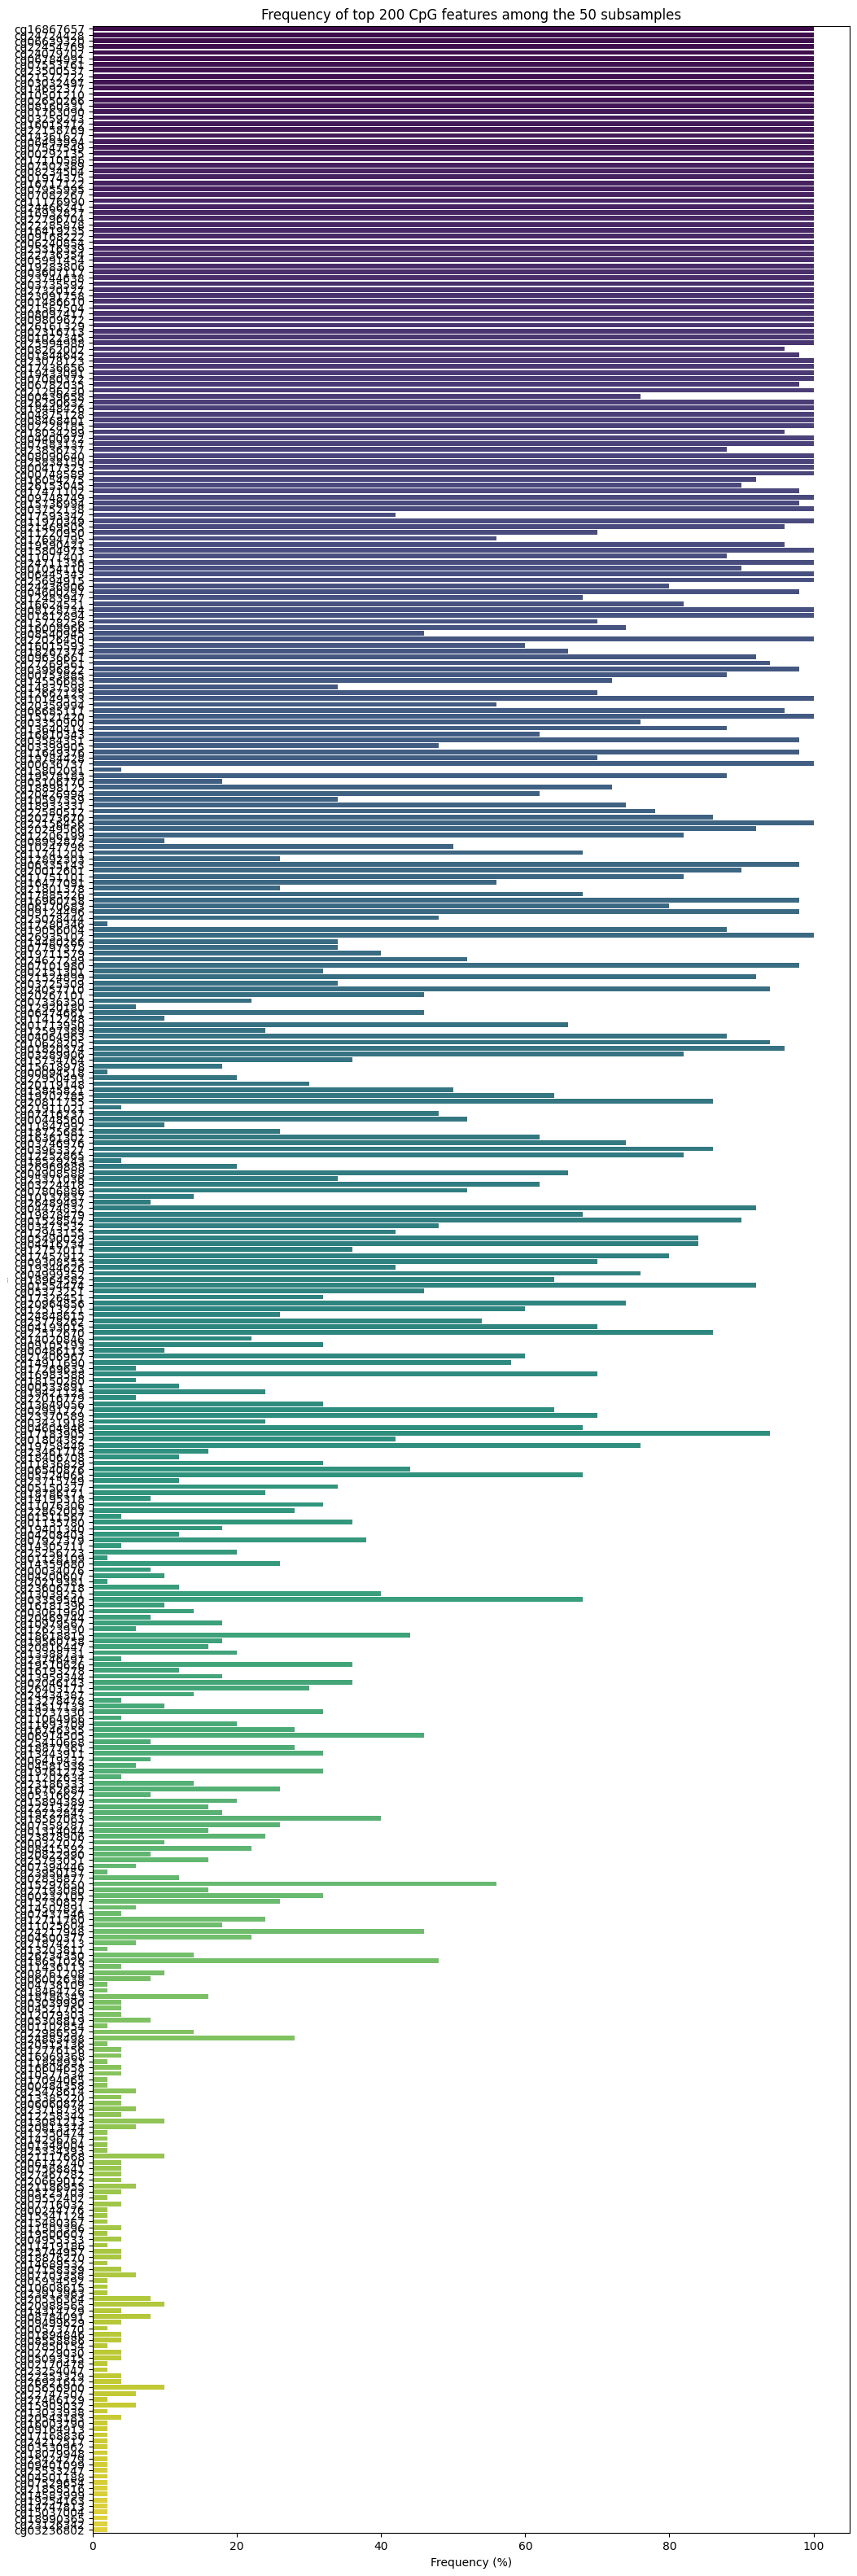

In [21]:
#Measure the frequency of each feature in the subsamples
from collections import Counter

counts = Counter(top200_allsubsamples)
frequency_series = pd.Series(counts)
frequency_norm = frequency_series/50 
frequency_perc = (frequency_series /50) *100 #number of total subsamples

os.makedirs('../figures/Task3_Figures', exist_ok=True)

plt.figure(figsize=(12,40))
sns.barplot(x=frequency_perc.values, y=frequency_perc.index, palette='viridis')
plt.title("Frequency of top 200 CpG features among the 50 subsamples")
plt.ylabel("CpG Site", fontsize=1)
plt.xlabel("Frequency (%)")
plt.savefig('../figures/Task3_Figures/Top200_CpG_Frequency_among_subsamples.png', dpi=300, bbox_inches='tight')
plt.show()


The number of stable features selected is: 186


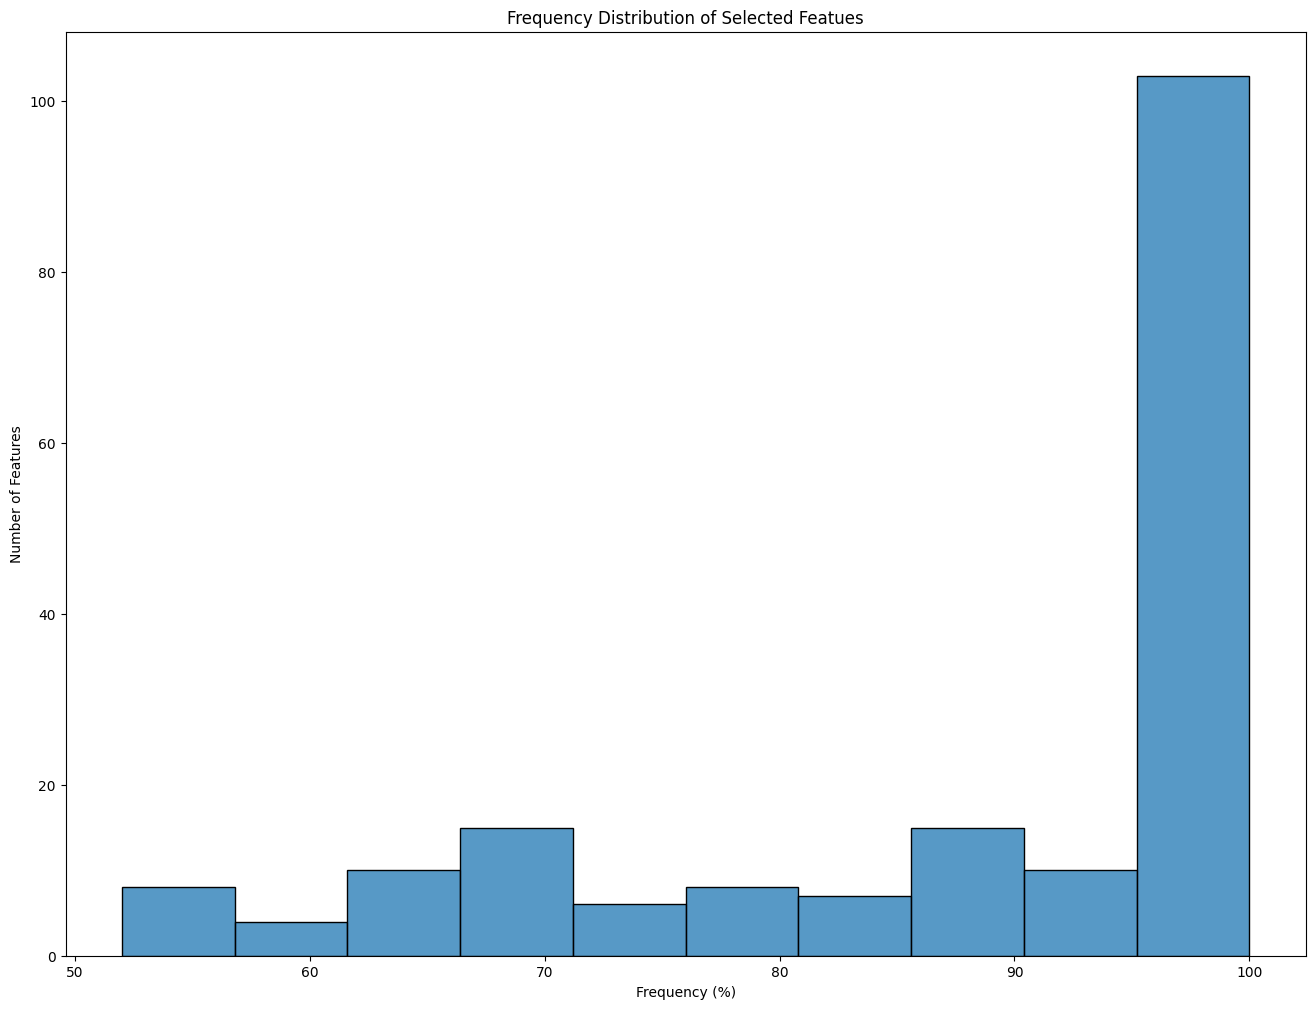

In [24]:
#Filter the results from running stability selection based on frequency - a feature is stable if it appears in more than half of the 50 resamples

stable_feature_freq = frequency_perc[frequency_perc > 50].sort_values(ascending=False)
print(f"The number of stable features selected is: {len(stable_feature_freq)}")

#Generate the selection-frequency distribution 

plt.figure(figsize=(16,12))
sns.histplot(stable_feature_freq, bins=10)
plt.title("Frequency Distribution of Selected Featues")
plt.ylabel("Number of Features")
plt.xlabel("Frequency (%)")
plt.savefig('../figures/Task3_Figures/Frequency_Distribution_Selected_Features.png', dpi=300, bbox_inches='tight')
plt.show()